## Overview

In this mini-project you will train, tune, and compare four binary classification algorithms on
a common dataset, and write a short technical report analysing when and why each method
succeeds or struggles. The goal is not merely to run existing implementations—it is to develop
intuition for decision boundaries, model capacity, and the bias–variance trade-off through direct
observation and experimentation.

## Dataset

Breast Cancer Wisconsin (Diagnostic). The dataset contains 569 samples with 30 real valued features derived from digitised images of fine-needle aspirate (FNA) biopsies. 
The binary label is malignant (1) vs. benign (0). It is available directly via:

<b>sklearn.datasets.load_breast_cancer()</b>

Use an 80/20 stratified train–test split with a fixed random seed (e.g. random_state = 42) throughout all experiments.

Bonus challenge. Repeat the entire pipeline on a second dataset of your choice (e.g. Pima Indians Diabetes or Ionosphere from the UCI repository) and comment on whether the relative ranking of methods changes.


## Methods

You must implement and evaluate the following four classifiers. You may use scikit-learn for all implementations—the focus is on understanding, tuning, and interpretation, not on reimplementing algorithms from scratch.

In [1]:
#import necessary libraries 

#loading the dataset
from sklearn.datasets import load_breast_cancer

# base libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# dataset modifiers
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# logistic regression
from sklearn.linear_model import LogisticRegression

# gradient discriminant analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# support vector machines
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

#model evaluation functions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, log_loss

Preparing & Exploring the dataset

Dataset Shape: 
(569, 31)

First 5 Rows: 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smo

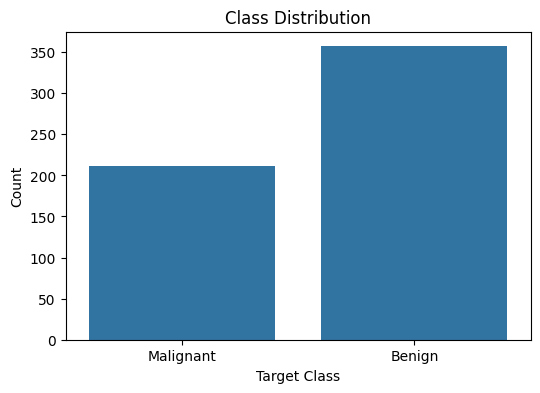

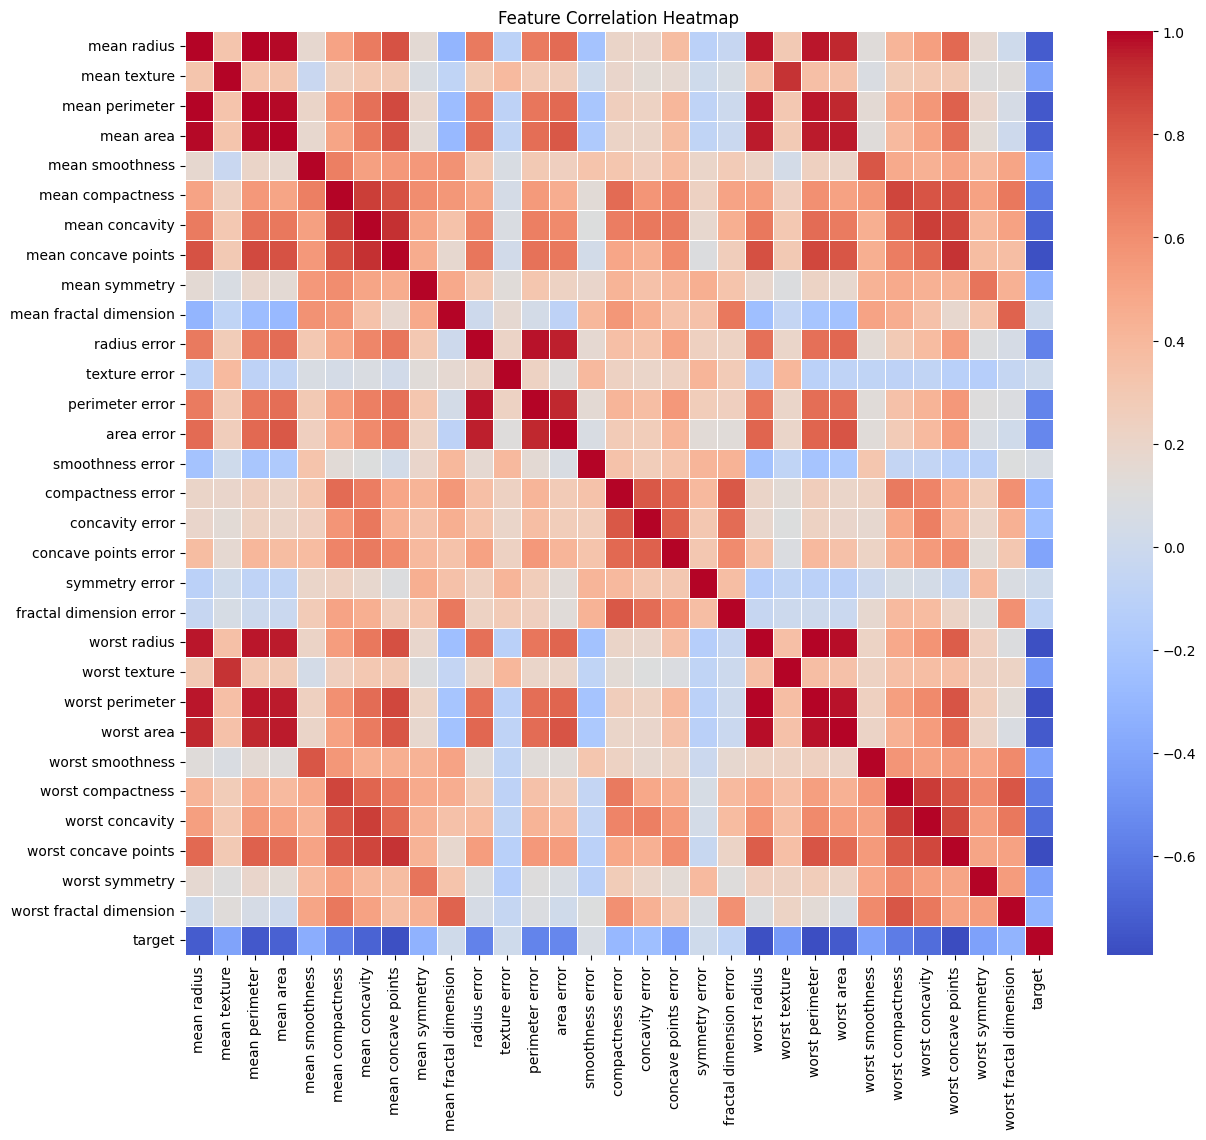


Training Set Shape:  (455, 30)
Testing Set Shape:  (114, 30)

Mean of Scaled Training Features (approx 0):
[-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]

Standard Deviation of Scaled Training Features (approx 1):
[1. 1. 1. 1. 1.]


In [3]:
np.random.seed(42)
pd.set_option('display.max_columns', None)

data = load_breast_cancer()

# display(data) 

# Features and labels
X = data.data
y = data.target

# Feature names
feature_names = data.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add target column
df['target'] = y



#simple dataset  analysis
print("Dataset Shape: ")
print(df.shape)

print("\nFirst 5 Rows: ")
display(df.head())

print("\nDataset Information: ")
print(df.info())

#check for columns will null values
print("\nMissing Values: ")
print(df.isnull().sum()) #looks like its a very good dataset, no nulls

print("\nClass Distribution:")
print(df['target'].value_counts()) # 1 - 357, 0 - 212

#class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()

#correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("\nTraining Set Shape: ", X_train.shape)
print("Testing Set Shape: ", X_test.shape)

#scaling the dimensions to normal distribution
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #fit transform is used to scale so that any training info isn't leaked 
X_test_scaled = scaler.transform(X_test) #transform is used to scale so that any testing info isn't leaked

#to check if the dimensions/features have been converted to a normal distribution
print("\nMean of Scaled Training Features (approx 0):")
print(np.mean(X_train_scaled, axis=0)[:5])

print("\nStandard Deviation of Scaled Training Features (approx 1):")
print(np.std(X_train_scaled, axis=0)[:5])

## Logistic Regression


Use L2 regularisation. Tune the inverse regularisation strength C via 5-fold cross-validation on the training set. Report the learned coefficient vector and identify the five most influential features (largest |wj|).

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Hyperparameter:
{'C': 1}

Best Cross-Validation Accuracy:
0.9802197802197803
Accuracy  : 0.9824561403508771
Precision : 0.9861111111111112
Recall    : 0.9861111111111112
F1-Score  : 0.9861111111111112


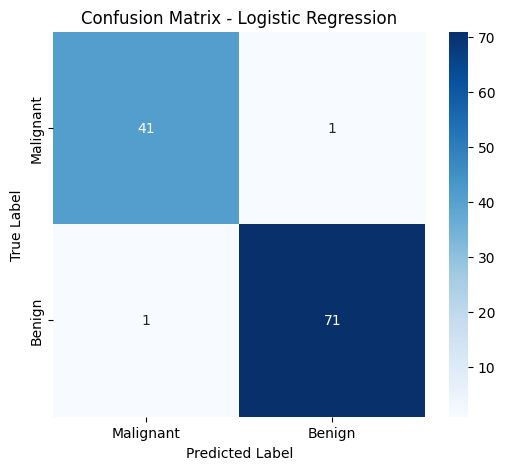


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== LEARNED COEFFICIENT VECTOR =====


,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.242272,1.242272
10,radius error,-1.087929,1.087929
23,worst area,-0.979282,0.979282
13,area error,-0.958096,0.958096
20,worst radius,-0.946000,0.946000
27,worst concave points,-0.945296,0.945296
28,worst symmetry,-0.928729,0.928729
26,worst concavity,-0.827180,0.827180
22,worst perimeter,-0.764807,0.764807
24,worst smoothness,-0.759567,0.759567



===== TOP 5 MOST INFLUENTIAL FEATURES =====


,Feature,Coefficient,Absolute Coefficient
21,worst texture,-1.242272,1.242272
10,radius error,-1.087929,1.087929
23,worst area,-0.979282,0.979282
13,area error,-0.958096,0.958096
20,worst radius,-0.946000,0.946000


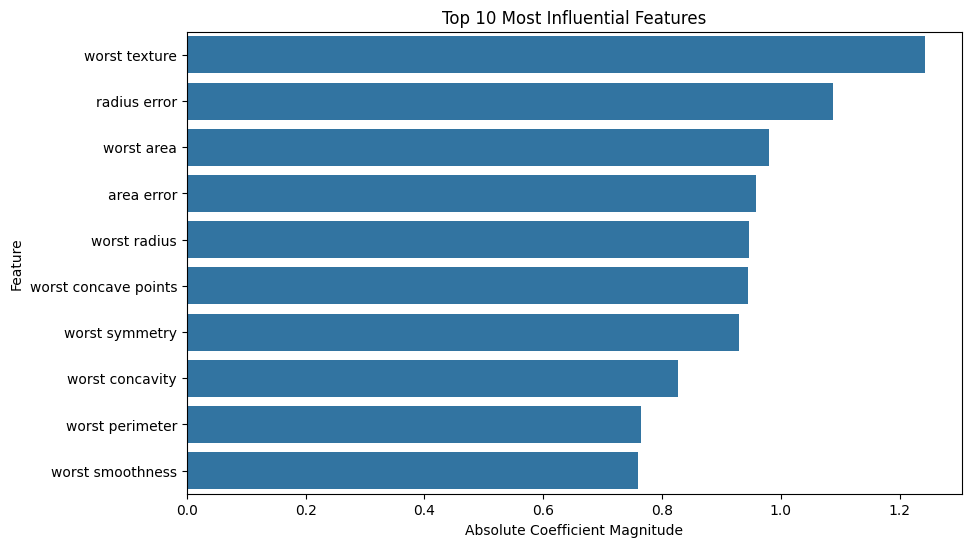

In [6]:
#init models
log_reg = LogisticRegression(penalty='l2', solver='liblinear', random_state=42, max_iter=1000)

#choices for grid search
param_grid = { 'C': [0.001, 0.01, 0.1, 1, 10, 100] }

grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Train using scaled data
grid_search.fit(X_train_scaled, y_train)

# best model according to grid search
best_log_reg = grid_search.best_estimator_

print("Best Hyperparameter:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

#predict with best model
y_pred = best_log_reg.predict(X_test_scaled)

#evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall    : {recall}")
print(f"F1-Score  : {f1}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()


print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

coefficients = best_log_reg.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names,
                        'Coefficient': coefficients,
                        'Absolute Coefficient': np.abs(coefficients)
                       }
             )


# Sort by absolute coefficient value
coef_df = coef_df.sort_values(by='Absolute Coefficient',
                              ascending=False
                  )

print("\n===== LEARNED COEFFICIENT VECTOR =====")
display(coef_df)

top5_features = coef_df.head(5)

print("\n===== TOP 5 MOST INFLUENTIAL FEATURES =====")
display(top5_features)

top10_features = coef_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Absolute Coefficient',
    y='Feature',
    data=top10_features
)

plt.title("Top 10 Most Influential Features")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")

plt.show()

## Gaussian Discriminant Analysis (GDA)

Fit class-conditional Gaussian distributions by maximum likelihood. 

Compare two variants: 

• LDA(Linear Discriminant Analysis): shared covariance matrix Σ across classes. 

• QDA(Quadratic Discriminant Analysis): separate covariance matrices Σ0,Σ1 per class. 

Report the log-likelihood on the training set for each variant and discuss which fits the data better and why

c:\Users\Sumed\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(



===== LDA PERFORMANCE =====
Accuracy  : 0.9561
Precision : 0.9467
Recall    : 0.9861
F1-Score  : 0.9660

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


===== QDA PERFORMANCE =====
Accuracy  : 0.9474
Precision : 0.9714
Recall    : 0.9444
F1-Score  : 0.9577

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



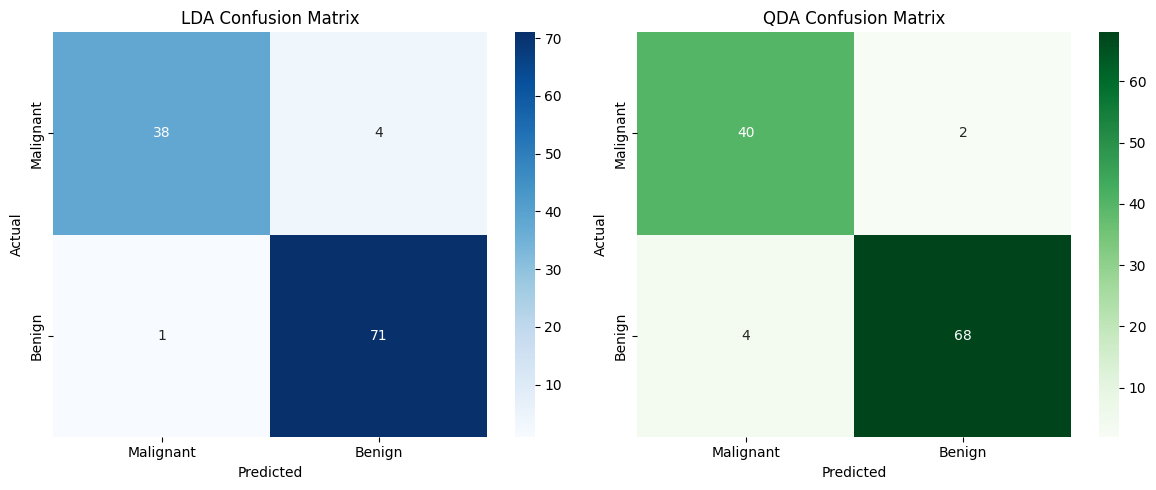


===== TRAINING LOG-LIKELIHOODS =====
LDA Log-Likelihood : -0.07851378040525471
QDA Log-Likelihood : -0.24096808390547791

===== CLASS PRIORS =====
LDA Class Priors:
[0.37362637 0.62637363]

QDA Class Priors:
[0.37362637 0.62637363]

===== LDA SHARED COVARIANCE MATRIX =====
[[ 4.63847582e-01  1.47715128e-02  4.52185370e-01  4.66511251e-01
  -1.01116658e-01  6.87602947e-02  1.61738074e-01  2.51502931e-01
  -9.91904452e-02 -3.01025640e-01  2.69374257e-01 -1.02328481e-01
   2.71225895e-01  3.43094334e-01 -1.66408991e-01 -1.44106319e-02
   4.72419234e-03  6.94744502e-02 -8.51698724e-02 -9.81736375e-02
   4.01641441e-01 -4.72389537e-02  3.92328390e-01  4.02995124e-01
  -1.94659350e-01 -2.93873779e-02  3.46717119e-02  1.51325813e-01
  -1.39265609e-01 -2.35994654e-01]
 [ 1.47715128e-02  8.32404987e-01  1.29401569e-02  1.79062878e-02
  -2.01733005e-01 -3.52794284e-02 -7.09325883e-03 -5.30601458e-02
  -9.09155418e-02 -8.36215574e-02  2.29062370e-02  3.91465687e-01
   2.80667760e-02  1.03860259e

,Model,Accuracy,Precision,Recall,F1-Score,Training Log-Likelihood
0,LDA,0.956140,0.946667,0.986111,0.965986,-0.078514
1,QDA,0.947368,0.971429,0.944444,0.957746,-0.240968


In [ ]:
#initialize models
lda = LinearDiscriminantAnalysis(store_covariance=True)

qda = QuadraticDiscriminantAnalysis(store_covariance=True)

#train models
lda.fit(X_train_scaled, y_train)

qda.fit(X_train_scaled, y_train)

#get predictions from the trained models
y_pred_lda = lda.predict(X_test_scaled)

y_pred_qda = qda.predict(X_test_scaled)

#defining a re-susable evaluate function
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {model_name} PERFORMANCE =====")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


# evaluate LDA
evaluate_model("LDA", y_test, y_pred_lda)

#evaluate QDA
evaluate_model("QDA", y_test, y_pred_qda)

#plotting confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)

sns.heatmap(
    cm_lda,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

axes[0].set_title("LDA Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# QDA
cm_qda = confusion_matrix(y_test, y_pred_qda)

sns.heatmap(
    cm_qda,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

axes[1].set_title("QDA Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# log likelyhood
# Predicted probabilities
lda_probs = lda.predict_proba(X_train_scaled)
qda_probs = qda.predict_proba(X_train_scaled)

# Negative log-loss = log-likelihood
lda_log_likelihood = -log_loss(y_train, lda_probs)
qda_log_likelihood = -log_loss(y_train, qda_probs)

print("\n===== TRAINING LOG-LIKELIHOODS =====")

print(f"LDA Log-Likelihood : {lda_log_likelihood}")
print(f"QDA Log-Likelihood : {qda_log_likelihood}")

# class priors
print("\n===== CLASS PRIORS =====")

print("LDA Class Priors:")
print(lda.priors_)

print("\nQDA Class Priors:")
print(qda.priors_)

#covariance matrices for both LDA and QDA
print("\n===== LDA SHARED COVARIANCE MATRIX =====")
print(lda.covariance_)

print("\n===== QDA CLASS-SPECIFIC COVARIANCE MATRICES =====")

for i, cov_matrix in enumerate(qda.covariance_):
    print(f"\nCovariance Matrix for Class {i}:")
    print(cov_matrix)

#comparison LDA VS QDA
results_df = pd.DataFrame({
    'Model': ['LDA', 'QDA'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lda),
        accuracy_score(y_test, y_pred_qda)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lda),
        precision_score(y_test, y_pred_qda)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lda),
        recall_score(y_test, y_pred_qda)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lda),
        f1_score(y_test, y_pred_qda)
    ],
    'Training Log-Likelihood': [
        lda_log_likelihood,
        qda_log_likelihood
    ]
})

print("\n===== LDA vs QDA COMPARISON =====")

display(results_df)

## Support Vector Machine (SVM) or Kernel SVM

Train with two kernel choices:

• Linear kernel.

• RBF (Gaussian) kernel.

Tune C for the linear SVM, and (C,γ) for the RBF SVM, via grid search with 5-fold cross validation.

Visualise the support vectors in the 2-D PCA projection described in Task 4. Report
the number of support vectors selected by each kernel.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
===== BEST LINEAR SVM PARAMETERS =====
{'C': 0.1}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== BEST RBF SVM PARAMETERS =====
{'C': 10, 'gamma': 0.01}

===== Linear SVM PERFORMANCE =====
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== RBF SVM PERFORMANCE =====
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    acc

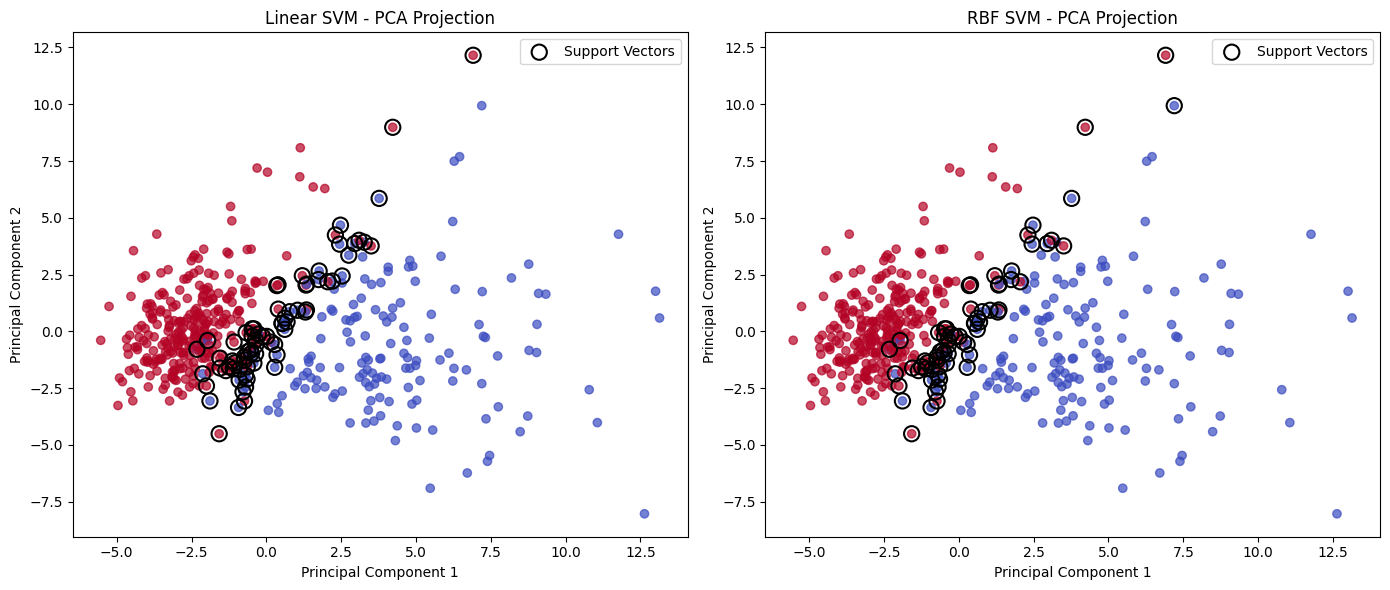

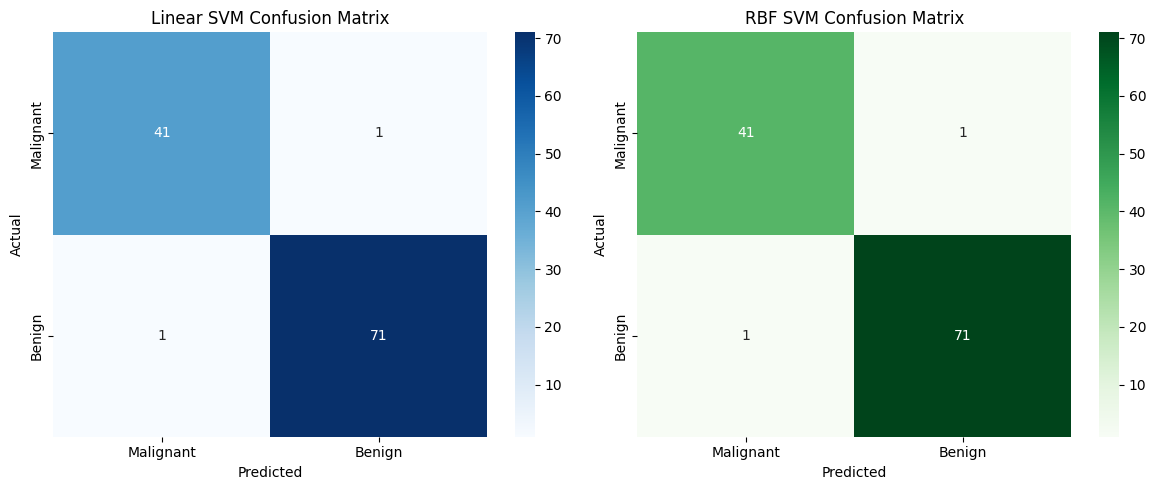


===== SVM COMPARISON TABLE =====


,Model,Best Parameters,Accuracy,Precision,Recall,F1-Score,Total Support Vectors
0,Linear SVM,{'C': 0.1},0.982456,0.986111,0.986111,0.986111,51
1,RBF SVM,"{'C': 10, 'gamma': 0.01}",0.982456,0.986111,0.986111,0.986111,52


In [ ]:
# linear scalar vector machines
linear_svm = SVC(kernel='linear')

linear_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

linear_grid = GridSearchCV(
    estimator=linear_svm,
    param_grid=linear_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

linear_grid.fit(X_train_scaled, y_train)

best_linear_svm = linear_grid.best_estimator_

print("===== BEST LINEAR SVM PARAMETERS =====")
print(linear_grid.best_params_)

# RBF SVM
rbf_svm = SVC(kernel='rbf')

rbf_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

rbf_grid = GridSearchCV(
    estimator=rbf_svm,
    param_grid=rbf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rbf_grid.fit(X_train_scaled, y_train)

best_rbf_svm = rbf_grid.best_estimator_

print("\n===== BEST RBF SVM PARAMETERS =====")
print(rbf_grid.best_params_)

# predictions
y_pred_linear = best_linear_svm.predict(X_test_scaled)

y_pred_rbf = best_rbf_svm.predict(X_test_scaled)

# evaluation function
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {name} PERFORMANCE =====")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


# evaluate
evaluate_model("Linear SVM", y_test, y_pred_linear)

evaluate_model("RBF SVM", y_test, y_pred_rbf)

# number of support vectors
print("\n===== NUMBER OF SUPPORT VECTORS =====")

print("Linear SVM:")
print(best_linear_svm.n_support_)
print("Total Support Vectors:",
      np.sum(best_linear_svm.n_support_))

print("\nRBF SVM:")
print(best_rbf_svm.n_support_)
print("Total Support Vectors:",
      np.sum(best_rbf_svm.n_support_))

#pca  2-d visualization
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

# train SVM wit principal components (with visualization)
linear_svm_pca = SVC(
    kernel='linear',
    C=best_linear_svm.C
)

rbf_svm_pca = SVC(
    kernel='rbf',
    C=best_rbf_svm.C,
    gamma=best_rbf_svm.gamma
)

linear_svm_pca.fit(X_train_pca, y_train)

rbf_svm_pca.fit(X_train_pca, y_train)

#identifying support vectors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# linear SVM visualization
axes[0].scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.7
)

# Highlight support vectors
axes[0].scatter(
    linear_svm_pca.support_vectors_[:, 0],
    linear_svm_pca.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

axes[0].set_title("Linear SVM - PCA Projection")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

# RBF SVM PCA (with visualization)
axes[1].scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    alpha=0.7
)

# Highlight support vectors
axes[1].scatter(
    rbf_svm_pca.support_vectors_[:, 0],
    rbf_svm_pca.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=1.5,
    label='Support Vectors'
)

axes[1].set_title("RBF SVM - PCA Projection")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear SVM
cm_linear = confusion_matrix(y_test, y_pred_linear)

sns.heatmap(
    cm_linear,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

axes[0].set_title("Linear SVM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

#RBF SVM
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1],
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

axes[1].set_title("RBF SVM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

#FINAL COMPARISON TABLE

svm_results = pd.DataFrame({
    'Model': ['Linear SVM', 'RBF SVM'],
    'Best Parameters': [
        linear_grid.best_params_,
        rbf_grid.best_params_
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf)
    ],
    'Total Support Vectors': [
        np.sum(best_linear_svm.n_support_),
        np.sum(best_rbf_svm.n_support_)
    ]
})

print("\n===== SVM COMPARISON TABLE =====")

display(svm_results)

===== UNPRUNED TREE PERFORMANCE =====
Accuracy  : 0.9123
Precision : 0.9559
Recall    : 0.9028
F1-Score  : 0.9286


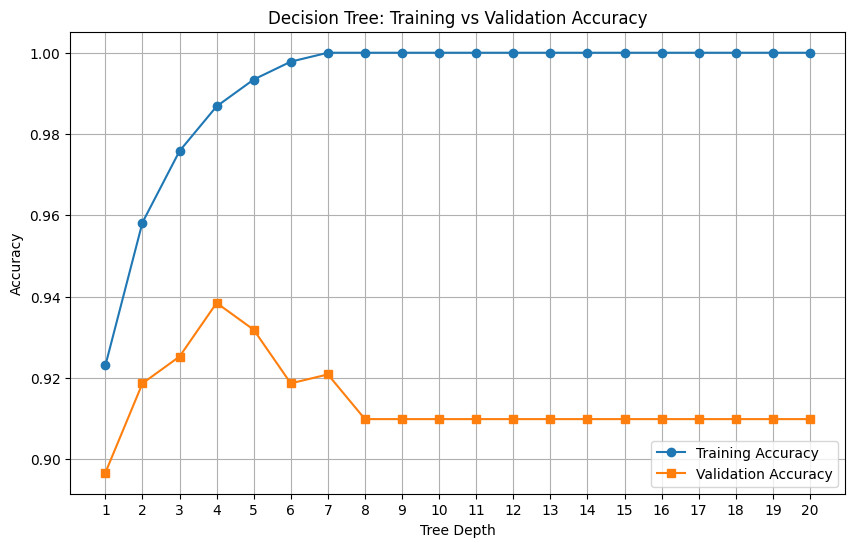


===== BEST TREE DEPTH =====
Best Depth: 4

===== FINAL PRUNED TREE PERFORMANCE =====
Accuracy  : 0.9386
Precision : 0.9577
Recall    : 0.9444
F1-Score  : 0.9510

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



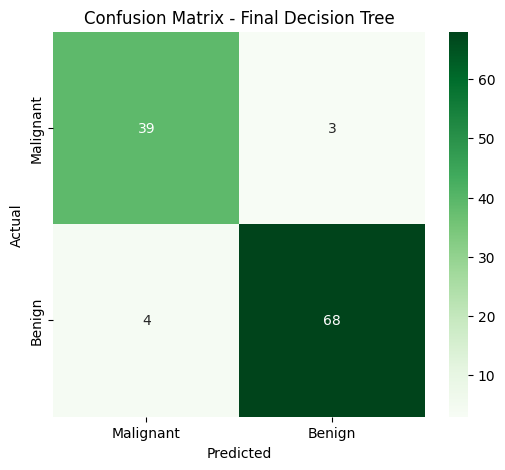

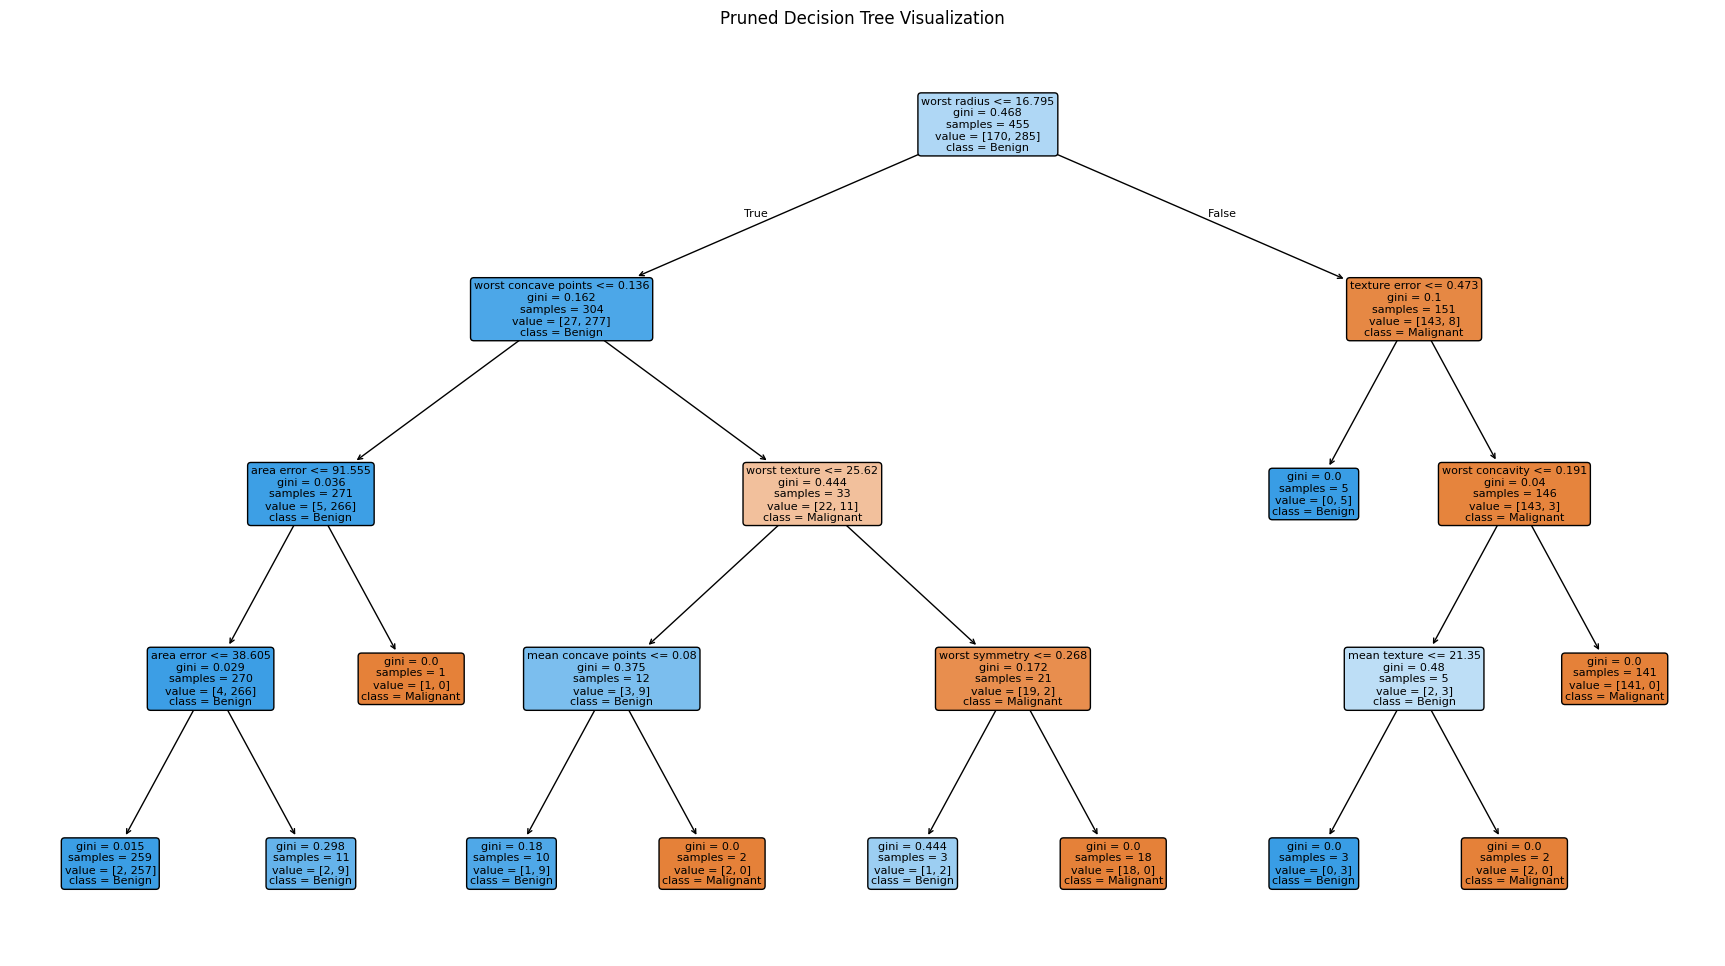


===== FEATURE IMPORTANCES =====


,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


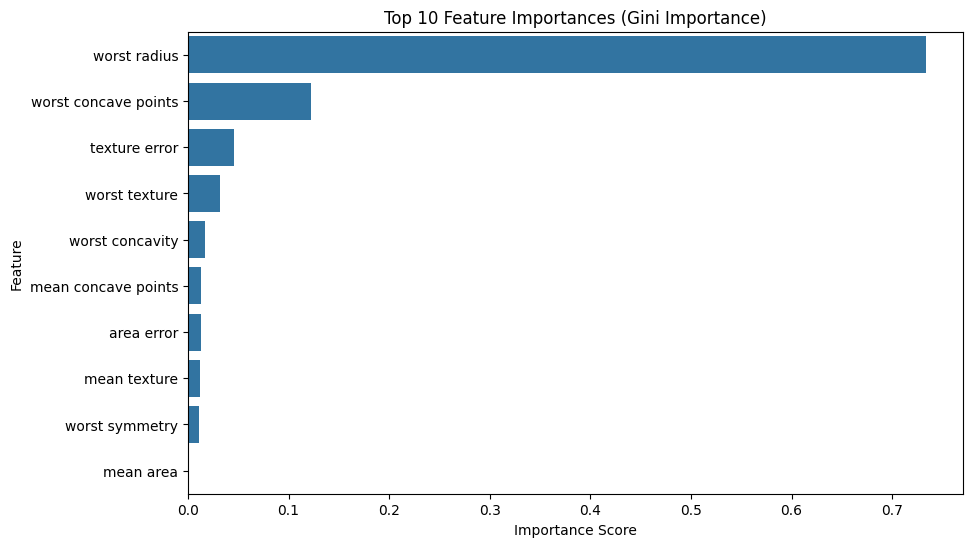


===== DECISION TREE SUMMARY =====


,Model,Depth,Accuracy,Precision,Recall,F1-Score
0,Unpruned Tree,7,0.912281,0.955882,0.902778,0.928571
1,Pruned Tree,4,0.938596,0.957746,0.944444,0.951049


In [ ]:
#train initial tree
unpruned_tree = DecisionTreeClassifier(
    random_state=42
)

unpruned_tree.fit(X_train, y_train)

#evaluate initial tree
y_pred_unpruned = unpruned_tree.predict(X_test)

print("===== UNPRUNED TREE PERFORMANCE =====")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_unpruned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_unpruned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_unpruned):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_unpruned):.4f}")

#exploring tree depth
depths = range(1, 21)

train_accuracies = []
validation_accuracies = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Training accuracy
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)

    # 5-fold cross-validation accuracy
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    validation_accuracies.append(cv_scores.mean())

# train vs validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracies,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    depths,
    validation_accuracies,
    marker='s',
    label='Validation Accuracy'
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Validation Accuracy")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()

#best depths
best_depth = depths[np.argmax(validation_accuracies)]

print("\n===== BEST TREE DEPTH =====")
print("Best Depth:", best_depth)

#train pruned tree

final_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_tree.fit(X_train, y_train)

#evaluate pruned tree
y_pred_final = final_tree.predict(X_test)

print("\n===== FINAL PRUNED TREE PERFORMANCE =====")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_final):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

#confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Final Decision Tree")

plt.show()

#pruned tree visualzation
# Assignment requires depth <= 5 visualization
visual_tree = DecisionTreeClassifier(
    max_depth=min(best_depth, 5),
    random_state=42
)

visual_tree.fit(X_train, y_train)

plt.figure(figsize=(22, 12))

plot_tree(
    visual_tree,
    feature_names=feature_names,
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Pruned Decision Tree Visualization")

plt.show()

# feature importance based on gini impurity index
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_tree.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n===== FEATURE IMPORTANCES =====")

display(feature_importance_df)

# important features
top10_importance = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10_importance
)

plt.title("Top 10 Feature Importances (Gini Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

#summary - decision tree
decision_tree_results = pd.DataFrame({
    'Model': ['Unpruned Tree', 'Pruned Tree'],
    'Depth': [
        unpruned_tree.get_depth(),
        final_tree.get_depth()
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_unpruned),
        accuracy_score(y_test, y_pred_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_unpruned),
        precision_score(y_test, y_pred_final)
    ],
    'Recall': [
        recall_score(y_test, y_pred_unpruned),
        recall_score(y_test, y_pred_final)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_unpruned),
        f1_score(y_test, y_pred_final)
    ]
})

print("\n===== DECISION TREE SUMMARY =====")

display(decision_tree_results)